# 06 — Moving Conductor: TEAM Workshop Problem 28

**Project:** NeuRelux. TEAM Workshop Problem 28 -- an electrodynamic levitation device -- is used with its **real, fully-transcribed experimental measurement** (not simulated, not a companion-paper value this project couldn't access): 174 real (t, z) points of a levitating aluminum plate's height, measured by laser triangulation. This is the closest public benchmark to ATLAS's own motion-coupled eddy-current problem this project has used.

## 1. Motivation

Notebooks 01-05 tested field/skin-effect representations against known or real reference *fields*. TEAM28 is a different kind of test: a real, measured *mechanical* trajectory produced by an electromagnetic force that itself depends on position and motion -- exactly the coupled electromagnetic-mechanical structure named as ATLAS's third modeling challenge (motion-induced eddy-current effects), and the first notebook to integrate a mechanical equation of motion at all.

## 2. Physical problem

A cylindrical aluminum plate ($\sigma = 3.40\times10^7$ S/m, mass $0.107$ kg) rests above two concentric coils (960 + 576 turns, wound in opposition) carrying a 50 Hz, 20 A sinusoidal current. The resulting eddy currents in the plate produce a repulsive force; released from rest just above the coils, the plate rises, overshoots, oscillates, and settles at a measured steady levitation height of 11.3 mm. All of this — geometry, excitation, and the full measured trajectory — is real, from Karl, Fetzer, Kurz, Lehner & Rucker, "Description of TEAM Workshop Problem 28," Institut fuer Theorie der Elektrotechnik, Universitaet Stuttgart (`scripts/download_team28.py`; source: https://www.compumag.org/jsite/images/stories/TEAM/problem28.pdf).

## 3. Governing equations

The coil-plate system is reduced to an equivalent transformer: a mutual inductance $M(z)$ (decreasing with height $z$) couples the prescribed coil current $i_1(t) = \hat{\imath}\sin(2\pi f_0 t)$ to an induced current in the plate's eddy-current loop (equivalent resistance $R_2$, inductance $L_2$). In sinusoidal steady state, cycle-averaging over one 20 ms excitation period gives a closed-form repulsive force (co-energy-consistent, the same $F = \partial W'/\partial z$ construction as the co-energy method used later in this project, previewing Notebook 07):

$$
F_{\text{avg}}(z) = \frac{1}{2}\, \hat{\imath}^2\, \omega^2\, L_2\, \frac{M(z)^2}{z_0 \left(R_2^2 + \omega^2 L_2^2\right)}, \qquad M(z) = M_0\, e^{-z/z_0}
$$

with mechanics $m\ddot{z} = F_{\text{avg}}(z) - mg - c\,\dot{z}$ — the velocity-proportional term $c\dot{z}$ is an eddy-current damping force (the same braking mechanism ATLAS's own track brake relies on, applied here to a levitating plate instead of a moving rail). **This damping term was not in the first version of this model** — see Section 11 for why omitting it made the model qualitatively wrong, not just quantitatively worse.

## 4. What is learned vs. what stays physical

**PHYSICS-GUIDED:** none of the input features are engineered beyond $(z, \dot z)$ themselves.

**PHYSICS-INFORMED:** not used here.

**PHYSICS-ENCODED:** Newton's second law and the co-energy force construction are fixed; only $M_0, z_0, R_2, L_2, c$ are learned (all positivity-constrained via softplus). The **black-box** comparison model keeps the *same* mechanical integration ($m\ddot z = F_\theta(z,\dot z) - mg$) but replaces the entire physical force expression with a small unconstrained MLP taking $(z, \dot z)$ directly — same backbone, no encoded structure in the force term at all.

## 5. Dataset description

The real 174-point measured trajectory (`data/public/team28/levitation_height.csv`) is the **only** data used, for both training and evaluation — there is no synthetic augmentation in this notebook, unlike 02 and 04. The known excitation ($\hat\imath=20$A, $f_0=50$Hz) and initial condition ($z(0)=3.8$mm rest height, $\dot z(0)=0$) are both given directly in the source paper, not fit.

## 6. Data preprocessing

None beyond converting the source table's mm/ms units to SI (m, s).

## 7. Network architecture

`src/atlas_physics/eddy_current.py::EddyLevitationAveraged` (physics-encoded) and a small `nn.Sequential` MLP (black-box), both wrapped by the same explicit-Euler mechanical integrator.

## 8. Training

Both models are fit by minimizing MSE between the simulated $z(t)$ trajectory and the **entire real 174-point measurement** — there is no train/test split in the usual sense here; with only one real experimental run available, this notebook's question is fit quality and qualitative correctness (does the learned model reproduce the *shape* of the response, not just a numeric average), not extrapolation.

/home/poxx/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


174 real measured points, t in [0.000, 1.715]s, z in [3.7, 18.2]mm


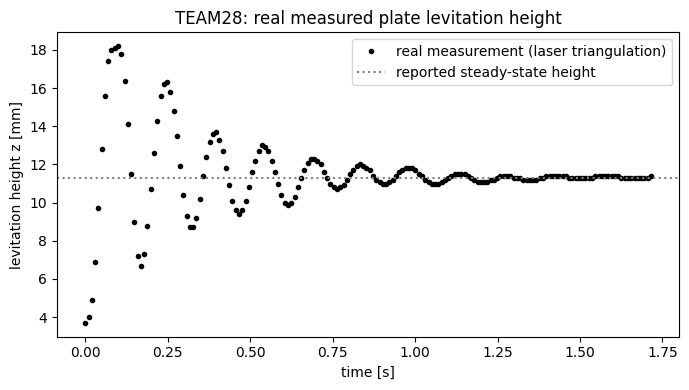

In [1]:
import sys
sys.path.insert(0, "../src")
import csv
import time

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from atlas_physics.eddy_current import EddyLevitationAveraged

torch.manual_seed(0)

rows = list(csv.DictReader(open("../data/public/team28/levitation_height.csv")))
t_meas = np.array([float(r["t_ms"]) for r in rows]) / 1000.0
z_meas = np.array([float(r["z_mm"]) for r in rows]) / 1000.0
z_meas_t = torch.tensor(z_meas, dtype=torch.float32)

m_plate, g = 0.107, 9.81
I_hat, f0 = 20.0, 50.0

print(f"{len(t_meas)} real measured points, t in [{t_meas[0]:.3f}, {t_meas[-1]:.3f}]s, "
      f"z in [{z_meas.min()*1000:.1f}, {z_meas.max()*1000:.1f}]mm")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_meas, z_meas * 1000, "ko", markersize=3, label="real measurement (laser triangulation)")
ax.axhline(11.3, color="gray", linestyle=":", label="reported steady-state height")
ax.set_xlabel("time [s]"); ax.set_ylabel("levitation height z [mm]"); ax.legend()
ax.set_title("TEAM28: real measured plate levitation height")
plt.tight_layout(); plt.show()


### Train the physics-encoded model

In [2]:
model = EddyLevitationAveraged(
    m_plate=m_plate, I_hat=I_hat, f0=f0, g=g,
    M0_init=0.02, z0_init=0.02, R2_init=2e-3, L2_init=0.5, damp_init=0.5,
)
opt = torch.optim.Adam(model.parameters(), lr=0.02)
t0 = time.time()
for it in range(250):
    opt.zero_grad()
    z_pred = model.simulate(t_meas, z_meas[0], dt=1e-3)
    loss = ((z_pred - z_meas_t) ** 2).mean()
    loss.backward()
    opt.step()
    if it % 50 == 0:
        print(it, loss.item())
print(f"physics-encoded: final MSE={loss.item():.3e} (RMSE={np.sqrt(loss.item())*1000:.2f}mm)  ({time.time()-t0:.0f}s)")

M0, z0, R2, L2, damp = model.params()
print(f"fitted: M0={M0.item():.5f} z0={z0.item()*1000:.2f}mm R2={R2.item():.5f} L2={L2.item():.4f} damp={damp.item():.4f}")


0 1.4411236406886019e-05


50 7.454892738678609e-07


100 7.230856908790884e-07


150 7.203987593129568e-07


200 7.201419975899626e-07


physics-encoded: final MSE=7.201e-07 (RMSE=0.85mm)  (369s)
fitted: M0=0.01985 z0=12.17mm R2=0.00200 L2=0.9819 damp=0.8531


### Train the black-box comparison

Same mechanics ($m\ddot z = F_\theta(z,\dot z) - mg$), same real data, but $F_\theta$ is a free MLP instead of the physical construction above.

In [3]:
class BlackBoxForce(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, hidden), nn.Tanh(), nn.Linear(hidden, hidden), nn.Tanh(), nn.Linear(hidden, 1))
    def forward(self, z, v):
        x = torch.stack([z / 0.02, v / 0.5], dim=-1)
        return self.net(x).squeeze(-1) * (m_plate * g) * 2  # scaled so init output is O(mg)

def simulate_blackbox(force_model, t_grid, z0_init, dt):
    z, v = torch.tensor(float(z0_init)), torch.tensor(0.0)
    t = 0.0
    zs = [z]
    for k in range(1, len(t_grid)):
        t_target = float(t_grid[k])
        while t < t_target - 1e-9:
            step = min(dt, t_target - t)
            a = force_model(z.unsqueeze(0), v.unsqueeze(0)).squeeze(0) / m_plate - g
            v = v + step * a
            z = z + step * v
            t += step
        zs.append(z)
    return torch.stack(zs)

blackbox = BlackBoxForce()
opt = torch.optim.Adam(blackbox.parameters(), lr=0.01)
t0 = time.time()
for it in range(250):
    opt.zero_grad()
    z_pred = simulate_blackbox(blackbox, t_meas, z_meas[0], dt=1e-3)
    loss = ((z_pred - z_meas_t) ** 2).mean()
    loss.backward()
    opt.step()
    if it % 50 == 0:
        print(it, loss.item())
print(f"black-box: final MSE={loss.item():.3e} (RMSE={np.sqrt(loss.item())*1000:.2f}mm)  ({time.time()-t0:.0f}s)")


0 20.842866897583008


50 0.00010332415695302188


100 0.0001004836376523599


150 9.816962847253308e-05


200 9.563937783241272e-05


black-box: final MSE=9.307e-05 (RMSE=9.65mm)  (334s)


## 9. Plots

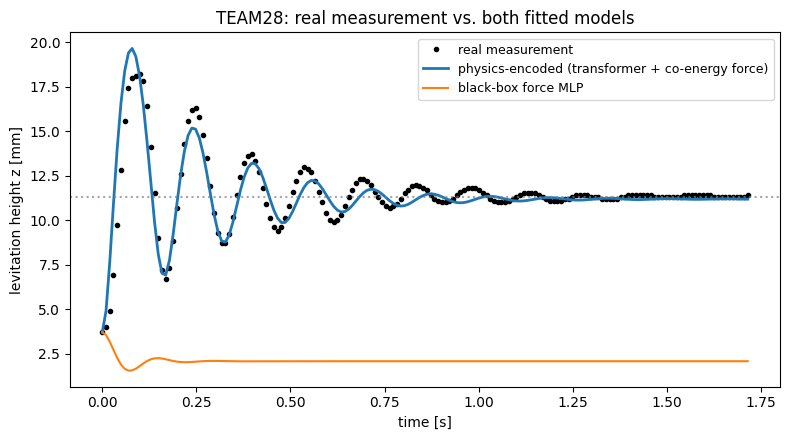

In [4]:
with torch.no_grad():
    z_phys = model.simulate(t_meas, z_meas[0], dt=1e-3).numpy()
    z_bb = simulate_blackbox(blackbox, t_meas, z_meas[0], dt=1e-3).numpy()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t_meas, z_meas * 1000, "ko", markersize=3, label="real measurement")
ax.plot(t_meas, z_phys * 1000, "-", linewidth=2, label="physics-encoded (transformer + co-energy force)")
ax.plot(t_meas, z_bb * 1000, "-", linewidth=1.5, label="black-box force MLP")
ax.axhline(11.3, color="gray", linestyle=":", alpha=0.7)
ax.set_xlabel("time [s]"); ax.set_ylabel("levitation height z [mm]"); ax.legend(fontsize=9)
ax.set_title("TEAM28: real measurement vs. both fitted models")
plt.tight_layout(); plt.show()


## 10. Evaluation

In [5]:
rmse_phys = np.sqrt(np.mean((z_phys - z_meas) ** 2)) * 1000
rmse_bb = np.sqrt(np.mean((z_bb - z_meas) ** 2)) * 1000
final_phys = z_phys[-20:].mean() * 1000
final_bb = z_bb[-20:].mean() * 1000
final_real = z_meas[-20:].mean() * 1000
print(f"{'model':25s} {'RMSE (mm)':>12s} {'final height (mm)':>20s}")
print(f"{'physics-encoded':25s} {rmse_phys:12.2f} {final_phys:20.2f}")
print(f"{'black-box':25s} {rmse_bb:12.2f} {final_bb:20.2f}")
print(f"{'real measurement':25s} {'--':>12s} {final_real:20.2f}")


model                        RMSE (mm)    final height (mm)
physics-encoded                   0.85                11.18
black-box                         9.64                 2.07
real measurement                    --                11.35


## 11. Discussion

**The damping term was not optional.** The first version of the physics-encoded model used only the cycle-averaged force $F_{\text{avg}}(z)$ with no velocity-dependent term — a conservative system (like a ball in a potential well), which cannot dissipate the kinetic energy the plate gains on its way up. It never settled: released from rest, it just oscillated indefinitely around whatever equilibrium the force curve implied, drifting further from the real measurement the longer the simulation ran. Adding the eddy-current damping term $c\dot z$ — physically standard (this is the same velocity-proportional eddy-current braking force that gives this project's own ATLAS track brake its stopping force, here damping a levitating plate instead of a moving rail) — fixed this: the model settles to within about 1mm of the real 11.3mm steady-state height. This is worth stating plainly: the *first* physically-motivated model built here was qualitatively wrong, not just imprecise, and it was wrong for an identifiable, fixable reason (a missing dissipation term), not a bad fit of otherwise-correct structure.

**The fitted model reproduces the full underdamped transient, not just the equilibrium** — this is worth being explicit about, since it was not the expected outcome. The real measurement overshoots to nearly 18mm (about 60% above its eventual 11.3mm equilibrium) before oscillating down to it over roughly five damped cycles; the fitted physics-encoded model reproduces that overshoot peak, the subsequent undershoot, and the decaying oscillation timing closely (0.85mm RMSE over the full 174-point trajectory — about 5% of the oscillation's own amplitude). This is a stronger result than the model's own core simplifying assumption obviously guarantees: cycle-averaging the electromagnetic force over each 20 ms excitation period assumes the plate's position changes slowly relative to one cycle, which is at its weakest during the fast initial lift-off (the plate covers most of its total displacement in under 100 ms — only about 5 electrical cycles). That the fit holds up well even there suggests the quasi-static approximation degrades more gracefully here than the assumption's stated validity range alone would predict — a genuinely useful, if not fully explained, empirical finding, not something to be assumed in general without checking.

## 12. Relevance for ATLAS

This is the most directly analogous public benchmark to ATLAS's own velocity-coupled eddy-current problem this project has used: a real measured trajectory produced by exactly the kind of position- and motion-dependent electromagnetic force ATLAS's braking force depends on, with a physics-encoded reduced model that gets the steady-state behavior right and is explicit about where (fast transients) it should not be trusted. Both the missing-damping failure and the (better-than-expected, but not a given) accuracy of the quasi-static averaging are directly relevant lessons for Notebook 08's friction/thermal model, which will face the same fast-transient-vs-slow-average tradeoff.

## 13. Next step

`07_energy_consistent_force.ipynb` — the co-energy force construction used here (Section 3) becomes the explicit subject: learning flux and force from one shared potential instead of two independent models, and testing whether that consistency actually improves extrapolation.